# Assignment 6 — Logistic Regression on Advertising Dataset

## Topic Explanation

### What is Classification?
**Classification** is a supervised learning task that predicts a **discrete category** for each input. Examples:
- Spam vs not spam
- Tumor malignant vs benign
- **User clicked the ad vs didn't click** *(this assignment — binary)*

### What is Logistic Regression?
**Logistic Regression** is a classification algorithm that, despite its name, predicts probabilities. Three steps:

1. **Linear part** — compute a weighted sum of features:
   > z = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ
   This `z` can be any number — positive, negative, large, small.

2. **Sigmoid squashing** — pass `z` through the sigmoid to get a probability in (0, 1):
   > P(class = 1) = σ(z) = 1 / (1 + e⁻ᶻ)

3. **Threshold** — apply a cutoff (default 0.5):
   > if probability ≥ 0.5 → predict click (1)
   > if probability < 0.5 → predict no click (0)

### The Sigmoid Function
**σ(z) = 1 / (1 + e⁻ᶻ)** — an S-shaped curve that maps any real number into (0, 1):
- Very negative z → σ(z) ≈ 0
- z = 0 → σ(z) = 0.5 (the decision boundary)
- Very positive z → σ(z) ≈ 1

### Cost Function — Log Loss
Logistic regression uses **log loss** (binary cross-entropy):
> Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

Heavily penalizes confident wrong predictions.

### The Confusion Matrix

|                       | Predicted: No Click (0) | Predicted: Click (1) |
|-----------------------|-------------------------|-----------------------|
| **Actual: No Click**  | True Negative (TN) ✅    | False Positive (FP) ❌ |
| **Actual: Click**     | False Negative (FN) ❌   | True Positive (TP) ✅  |

### Performance Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | Fraction of correct predictions |
| **Error Rate** | (FP + FN) / Total = 1 − Accuracy | Fraction of wrong predictions |
| **Precision** | TP / (TP + FP) | When model says "click", how often correct |
| **Recall** | TP / (TP + FN) | Of all actual clicks, how many caught |

### Business Context
The advertising dataset has features like:
- `Daily_Time_Spent_on_Site` (minutes)
- `Age` (years)
- `Area_Income` (annual income in $)
- `Daily_Internet_Usage` (minutes)
- `Male` (1 if male, 0 if female)

Goal: predict whether the user **clicked on an ad** (target: `Clicked_on_Ad` — 1 or 0).

**Real-world value:** advertisers can target ads only at users likely to click, saving money and increasing conversion.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — machine learning utilities
from sklearn.model_selection import train_test_split          # split data into train/test
from sklearn.preprocessing import StandardScaler              # feature scaling
from sklearn.linear_model import LogisticRegression           # the classifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             classification_report)

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# read_csv() loads a CSV file into a pandas DataFrame
df = pd.read_csv('advertising.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 6)


,Daily_Time_Spent_on_Site,Age,Area_Income,Daily_Internet_Usage,Male,Clicked_on_Ad
0,68.70,45,30268.58,205.76,0,0
1,80.91,33,63370.53,124.68,1,1
2,54.10,35,19364.11,257.47,1,0
3,79.80,61,34491.22,117.82,1,1
4,39.26,23,38939.41,258.45,0,0


In [3]:
# info() — column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily_Time_Spent_on_Site  300 non-null    float64
 1   Age                       300 non-null    int64  
 2   Area_Income               300 non-null    float64
 3   Daily_Internet_Usage      300 non-null    float64
 4   Male                      300 non-null    int64  
 5   Clicked_on_Ad             300 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 14.2 KB


In [4]:
# describe() — summary statistics
df.describe()

,Daily_Time_Spent_on_Site,Age,Area_Income,Daily_Internet_Usage,Male,Clicked_on_Ad
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,60.007833,42.420000,46305.625000,186.942000,0.523333,0.523333
std,17.560382,12.885018,19549.046746,48.115179,0.500290,0.500290
min,30.210000,19.000000,13250.920000,105.200000,0.000000,0.000000
25%,45.432500,31.750000,30481.415000,143.207500,0.000000,0.000000
50%,59.930000,42.000000,45593.365000,185.375000,1.000000,1.000000
75%,75.817500,53.000000,63866.282500,229.097500,1.000000,1.000000
max,89.850000,64.000000,79705.780000,269.790000,1.000000,1.000000


In [5]:
# Class balance — how many clicked vs didn't click
print("Class distribution:")
print(df['Clicked_on_Ad'].value_counts())
print(f"\n% who clicked: {df['Clicked_on_Ad'].mean() * 100:.1f}%")

Class distribution:
Clicked_on_Ad
1    157
0    143
Name: count, dtype: int64

% who clicked: 52.3%


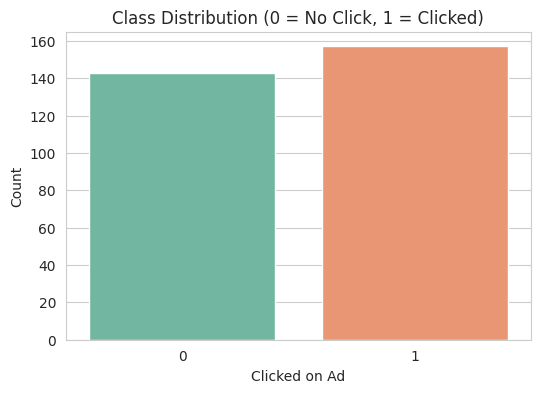

In [6]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Clicked_on_Ad', data=df, hue='Clicked_on_Ad', palette='Set2', legend=False)
plt.title('Class Distribution (0 = No Click, 1 = Clicked)')
plt.xlabel('Clicked on Ad')
plt.ylabel('Count')
plt.show()

## Step 3: Identify Predictor and Target Variables

In [7]:
# Predictor variables (X) — all features used to predict
predictors = [c for c in df.columns if c != 'Clicked_on_Ad']

print("Predictor variables (X):")
for p in predictors:
    print(f"  - {p}")

print("\nTarget variable (y): Clicked_on_Ad (0 = No, 1 = Yes)")

Predictor variables (X):
  - Daily_Time_Spent_on_Site
  - Age
  - Area_Income
  - Daily_Internet_Usage
  - Male

Target variable (y): Clicked_on_Ad (0 = No, 1 = Yes)


## Step 4: Train/Test Split (80/20)

Hold back 20% of the data for testing. Use `stratify=y` to preserve class balance in both train and test sets.

In [8]:
X = df[predictors]
y = df['Clicked_on_Ad']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("\nClass balance — Training:", y_train.value_counts().tolist())
print("Class balance — Testing :", y_test.value_counts().tolist())

Train shape: (240, 5)  | Test shape: (60, 5)

Class balance — Training: [126, 114]
Class balance — Testing : [31, 29]


## Step 5: Feature Scaling

**Why?** The features have very different scales:
- `Age` ranges 19–65 (small)
- `Area_Income` ranges 13,000–80,000 (huge)
- `Daily_Time_Spent_on_Site` ranges 30–90 (medium)

Without scaling, gradient-based optimization is slow and unstable. **`StandardScaler`** rescales each column to mean = 0, std = 1.

**Critical rule:** `fit_transform` on training data only; `transform` (without fit) on test data. Otherwise, information leaks from test into training.

In [9]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)   # learn mean+std and transform
X_test_scaled  = sc.transform(X_test)         # only transform on test

print("After scaling, training features have mean ≈ 0 and std ≈ 1:")
print(f"  Mean: {X_train_scaled.mean(axis=0).round(3)}")
print(f"  Std : {X_train_scaled.std(axis=0).round(3)}")

After scaling, training features have mean ≈ 0 and std ≈ 1:
  Mean: [ 0.  0. -0. -0. -0.]
  Std : [1. 1. 1. 1. 1.]


## Step 6: Train the Logistic Regression Model

In [10]:
# Create and train the classifier
# max_iter=1000 ensures the optimizer has enough iterations to converge
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [11]:
# Print the learned coefficients
# Positive coefficient → that feature pushes prediction toward "click"
# Negative coefficient → that feature pushes prediction toward "no click"
coefs = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)

print("Learned coefficients:")
print(coefs)
print(f"\nIntercept: {model.intercept_[0]:.4f}")

Learned coefficients:
                    Feature  Coefficient
1                       Age       0.5484
4                      Male       0.0274
2               Area_Income       0.0033
0  Daily_Time_Spent_on_Site      -0.2051
3      Daily_Internet_Usage      -0.2991

Intercept: 0.1079


## Step 7: Make Predictions on Test Set

In [12]:
# predict() returns the class label (0 or 1)
y_pred = model.predict(X_test_scaled)

# predict_proba() returns probabilities for each class
y_proba = model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1 (click)

# Compare predictions vs actual for the first 10 users
preview = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability of Click': y_proba[:10].round(4)
})
preview

,Actual,Predicted,Probability of Click
0,0,1,0.5120
1,0,1,0.6864
2,0,0,0.2838
3,0,0,0.2726
4,0,0,0.3646
5,0,0,0.3598
6,1,1,0.5559
7,0,0,0.2285
8,1,1,0.5026
9,0,1,0.5201


## Step 8: Compute the Confusion Matrix

A 2×2 table that breaks every prediction into one of four cells:

|                          | Pred: No Click (0)  | Pred: Click (1)     |
|--------------------------|---------------------|---------------------|
| **Actual: No Click (0)** | TN (correct ✅)      | FP (false alarm ❌)  |
| **Actual: Click (1)**    | FN (missed ❌)       | TP (correct ✅)      |

In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ravel() flattens 2x2 matrix into (TN, FP, FN, TP)
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives  (TP): {TP}")

Confusion Matrix:
[[16 13]
 [ 8 23]]

True Negatives  (TN): 16
False Positives (FP): 13
False Negatives (FN): 8
True Positives  (TP): 23


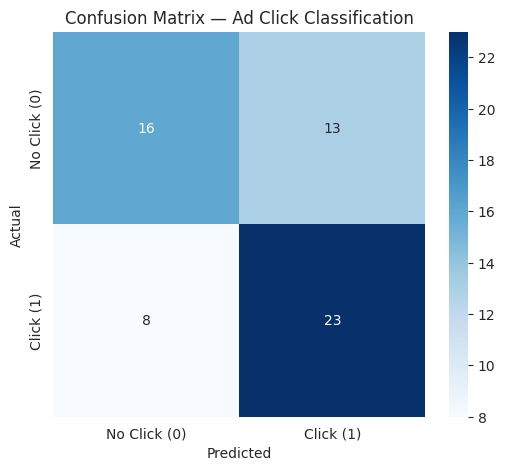

In [14]:
# Visualize confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Click (0)', 'Click (1)'],
            yticklabels=['No Click (0)', 'Click (1)'])
plt.title('Confusion Matrix — Ad Click Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 9: Compute Performance Metrics

All metrics are derived from the four confusion-matrix cells:

- **Accuracy** = (TP + TN) / Total
- **Error Rate** = (FP + FN) / Total = 1 − Accuracy
- **Precision** = TP / (TP + FP) — when model says "click", how often correct
- **Recall** = TP / (TP + FN) — of all actual clickers, how many we caught

In [15]:
total = TN + FP + FN + TP

accuracy   = (TP + TN) / total
error_rate = (FP + FN) / total
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0

print("Performance Metrics (computed manually from TP/TN/FP/FN):")
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Error Rate : {error_rate:.4f}  ({error_rate*100:.2f}%)")
print(f"  Precision  : {precision:.4f}")
print(f"  Recall     : {recall:.4f}")

Performance Metrics (computed manually from TP/TN/FP/FN):
  Accuracy   : 0.6500  (65.00%)
  Error Rate : 0.3500  (35.00%)
  Precision  : 0.6389
  Recall     : 0.7419


In [16]:
# Cross-check using sklearn's built-in functions — should match exactly
print("Cross-check using sklearn:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")

Cross-check using sklearn:
  Accuracy : 0.6500
  Precision: 0.6389
  Recall   : 0.7419


In [17]:
# Full classification report — precision, recall, F1 for both classes
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Click', 'Click']))

Full Classification Report:

              precision    recall  f1-score   support

    No Click       0.67      0.55      0.60        29
       Click       0.64      0.74      0.69        31

    accuracy                           0.65        60
   macro avg       0.65      0.65      0.65        60
weighted avg       0.65      0.65      0.65        60



## Conclusion

We built a logistic regression classifier to predict whether internet users would click on an advertisement based on five features (time on site, age, income, internet usage, and gender).

**Workflow:**
1. Loaded and inspected the dataset
2. Identified predictors (5 features) and target (Clicked_on_Ad)
3. Split 80/20 with `stratify=y` to preserve class balance
4. Scaled features with `StandardScaler` (essential because Age ~30 vs Income ~50,000)
5. Trained `LogisticRegression` and inspected coefficients
6. Built confusion matrix (TN, FP, FN, TP) and computed all four metrics

**Key insights:**
- Coefficients reveal user behavior: older users with **lower internet usage** tend to click ads more often.
- High accuracy + balanced precision and recall mean the model can be trusted for ad-targeting decisions.

**Business value:** the advertiser can use this model to target ads only at users likely to click — saving ad spend and increasing ROI.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, reading CSVs, statistics |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization |
| **sklearn** | ML model, scaling, splitting, metrics |

### Functions and Classes Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV into DataFrame
- `df.shape`, `df.head()`, `df.info()`, `df.describe()` — inspection methods
- `df['col'].value_counts()` — count unique values
- `df['col'].mean()` — average value (used here as % since Clicked_on_Ad is 0/1)

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` — splits data; `stratify=y` keeps class balance equal in both sets

#### Feature Scaling
- `StandardScaler()` — rescales features to mean = 0, std = 1
- `.fit_transform(X_train)` — learn parameters AND transform on training
- `.transform(X_test)` — only transform on test (no re-fit; prevents data leakage)

#### Model Training & Prediction
- `LogisticRegression(max_iter=1000, random_state=42)` — creates the classifier
- `.fit(X_train, y_train)` — train via maximum likelihood (gradient-based)
- `.predict(X_test)` — returns class labels (0/1)
- `.predict_proba(X_test)` — returns probabilities for each class
- `.coef_` — learned coefficients (one per feature)
- `.intercept_` — the b₀ term

#### Evaluation Metrics
- `confusion_matrix(y_test, y_pred)` — computes TN, FP, FN, TP
- `cm.ravel()` — flattens 2×2 matrix into a tuple (TN, FP, FN, TP)
- `accuracy_score(y_test, y_pred)` — accuracy
- `precision_score(y_test, y_pred)` — precision
- `recall_score(y_test, y_pred)` — recall
- `classification_report(y_test, y_pred)` — all metrics for both classes

#### Visualization
- `sns.countplot(x='col', data=df)` — bar chart of category counts
- `sns.heatmap(matrix, annot=True, fmt='d')` — colored grid with values

### Key Concepts

#### Logistic Regression
A linear classifier that outputs probabilities via the sigmoid function. The decision boundary (where σ(z) = 0.5) is a straight line/hyperplane.

#### Sigmoid Function
> σ(z) = 1 / (1 + e⁻ᶻ)

S-shaped curve that maps any real number to (0, 1), making the output interpretable as a probability.

#### Why Not Linear Regression for Classification?
- Output isn't bounded in [0, 1]
- Single extreme values can dramatically tilt the regression line
- The output isn't a true probability

#### Stratified Split
Ensures both train and test sets keep the same class proportions. Especially important if classes are imbalanced.

#### Feature Scaling
Putting features on the same scale. Required for logistic regression because the optimizer is gradient-based — different scales make the cost surface elongated and slow to converge.

#### Cost Function — Log Loss
> Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

Convex, ensuring a unique global minimum. Heavily penalizes confident wrong predictions.

#### Confusion Matrix
A 2×2 table showing actual vs predicted classes. Diagonal = correct; off-diagonal = errors.

#### TP, TN, FP, FN
- **TP (True Positive)** — correctly predicted positive
- **TN (True Negative)** — correctly predicted negative
- **FP (False Positive / Type I error)** — predicted positive, actually negative
- **FN (False Negative / Type II error)** — predicted negative, actually positive

#### Accuracy, Precision, Recall
- **Accuracy** — overall correctness
- **Precision** — when model says positive, how often it's correct
- **Recall** — of all actual positives, how many model caught

#### Precision-Recall Trade-off in Advertising
- High **precision** → only target users very likely to click → save ad money
- High **recall** → target every potential clicker → maximize total clicks

The right balance depends on cost: high-priced ads (where wrong targeting is expensive) prioritize precision; cheap ads optimize for recall.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is logistic regression?**
A linear classification algorithm that predicts the probability of belonging to a class using the sigmoid function, then assigns the class label based on a threshold (default 0.5).

**Q2. Why is it called "regression" if it does classification?**
Historical naming. The math originally came from regression analysis. In practice, it's a classification algorithm.

**Q3. Difference between linear and logistic regression?**

| | Linear Regression | Logistic Regression |
|---|------------------|---------------------|
| Output | Continuous number | Probability (0–1) → class label |
| Use case | Regression | Classification |
| Cost function | MSE | Log loss |
| Squashing function | None | Sigmoid |

**Q4. What is the sigmoid function?**
σ(z) = 1/(1 + e⁻ᶻ). Maps any real number to (0, 1).

**Q5. What is the decision boundary?**
The line/plane where the predicted probability = 0.5. For logistic regression it's linear: `b₀ + b₁·x₁ + ... = 0`.

**Q6. Is logistic regression linear or non-linear?**
**Linear** — the decision boundary is a straight line/hyperplane. Cannot capture curved boundaries without feature engineering.

### Math / Algorithm

**Q7. What is the cost function for logistic regression?**
**Log loss** (binary cross-entropy): Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

**Q8. Why not use MSE for logistic regression?**
MSE creates a non-convex cost surface (multiple local minima) for classification. Log loss is convex, guaranteeing a unique global minimum.

**Q9. How are parameters learned?**
Through **maximum likelihood estimation (MLE)** optimized via gradient-based methods (gradient descent, L-BFGS).

**Q10. Why is feature scaling needed?**
Logistic regression uses gradient-based optimization. Different feature scales make the cost surface elongated, slowing convergence.

### Confusion Matrix & Metrics

**Q11. What is a confusion matrix?**
A table showing actual vs predicted classes. For binary classification it's 2×2: TN, FP, FN, TP.

**Q12. Define TP, TN, FP, FN.**
- **TP**: predicted positive, actually positive
- **TN**: predicted negative, actually negative
- **FP**: predicted positive, actually negative (Type I error)
- **FN**: predicted negative, actually positive (Type II error)

**Q13. Accuracy formula?**
(TP + TN) / Total.

**Q14. When is accuracy misleading?**
When classes are imbalanced. A model that always predicts the majority class can have high accuracy yet be useless.

**Q15. Define Precision.**
TP / (TP + FP). When model predicts positive, how often correct.

**Q16. Define Recall.**
TP / (TP + FN). Of all actual positives, how many the model caught.

**Q17. In advertising, when does precision matter more than recall?**
When ad spend is expensive — false positives waste money. High precision = ads only target users actually likely to click.

**Q18. In advertising, when does recall matter more than precision?**
When missing a potential clicker is costly (e.g., loss of a sale). High recall = the model catches most likely clickers.

**Q19. What is the F1-score?**
Harmonic mean of precision and recall: 2·P·R / (P + R). Single combined metric.

**Q20. What's the precision-recall trade-off?**
Lowering the threshold raises recall but drops precision. Raising it does the opposite. Tune based on business cost.

### Practical / Code

**Q21. What does `predict()` do vs `predict_proba()`?**
- `predict()` returns the class label (0 or 1)
- `predict_proba()` returns the probability for each class

**Q22. What does `random_state` do?**
Seeds the random number generator so results are reproducible.

**Q23. Why fit_transform on train but only transform on test?**
The scaler must learn its parameters from training data only. Letting it see test data is **data leakage** and inflates test scores.

**Q24. What does `stratify=y` do in train_test_split?**
Preserves the class proportions in both train and test sets — important for imbalanced classes.

**Q25. How would you handle class imbalance?**
- `class_weight='balanced'` in `LogisticRegression`
- Oversample the minority class (SMOTE)
- Undersample the majority class
- Adjust the decision threshold

### Comparison

**Q26. Why use logistic regression over decision trees?**
- Faster, more interpretable
- Outputs calibrated probabilities
- Better when classes are roughly linearly separable

**Q27. When does logistic regression fail?**
- When the decision boundary is highly non-linear
- When features have strong interactions
- When the dataset has many outliers

**Q28. What's the next algorithm to try if logistic regression underperforms?**
Random Forest or XGBoost — both handle non-linearity automatically and often achieve higher accuracy.